# Cross-Domain Trace Analysis (S1 / S2 / S3)

Exploratory extension, **not** part of the core Arm A/B research question -- see
`docs/equivalence/cross-domain-analysis-design.md` for the full proposed scope
(topological analysis, shared-characteristic analysis, category-theoretic
scaffolding) and `docs/DECISIONS.md` #11/#12/#14/#18/#19 for what was actually
built and why.

**Document order, reorganized 2026-08-06** (`docs/DECISIONS.md` #19) to match
the design doc's own S1/S2/S3 structure instead of build order (S2 and S1.3
were built first, cheap reuse of existing trace columns; S1.1/S1.2/S1.4/S1.5
came later, needing heavier deps) -- reading top to bottom:

1. **S1** -- topology (S1.1 disconnectivity, S1.2 persistent homology, S1.3 trap
   rate, S1.4 Mapper, S1.5 Forman-Ricci curvature -- in that order now)
2. **S2** -- shared characteristics without reduction
3. **S3** -- category-theoretic scaffolding (status transition matrix)
4. **Extensions beyond the design doc's scope** -- connectivity-pruning
   before/after, the S1 null-model control, and the Arm B x topology sweep,
   kept visibly separate from the S1/S2/S3 build above rather than interleaved
   with it

`ripser`/`persim` (S1.2), `networkx`/`GraphRicciCurvature` (S1.5) are
installed; S1.4's Mapper is implemented directly (`analysis/mapper.py`)
rather than via `kmapper`, since the doc calls for graph-adjacency clustering
within each filter interval, not `kmapper`'s default Euclidean clusterer.
`giotto-tda` is still not used -- `ripser`+`persim` cover the doc's scoped-down
"(a) feature embedding first" request without it.

**S1.1, S1.2, and S1.4 are population comparisons** (`POP_SAMPLE_SIZE`
instances per domain, fixed seed) rather than single hand-picked instances --
an earlier single-/dual-instance version of each existed first, and was
replaced after review: a picture of one or two instances doesn't establish
that a difference holds generally, and says little about the *nature* of
either domain's search space as a population property. **S1.5 keeps its
single-instance plot** (its value is showing *where* one tree is locally
bottlenecked, which pooling would erase) and adds a separate population
view alongside it. Population comparisons use scalar summary statistics
(bar counts, total persistence, fragmentation ratio, mean curvature) plus a
Mann-Whitney U test, not full persistence-landscape/image averaging --
`persim` has `PersLandscapeApprox`/`PersistenceImager` for that if more
resolution is wanted later; the scalar-summary route was chosen to avoid
taking on an unfamiliar library API under time pressure, not because
landscapes wouldn't be better.

Everything here reads `results/traces/*.csv` through the `analysis/` package --
the S2/S1.3/S3.1/3.2 cells reuse the same functions `scripts/analyze_traces.py`
uses; S1.1/1.2/1.4/1.5 are new (this session) and only live here so far, not
in the CLI script.

**Treat this as directional, not confirmatory** -- the sample is whatever's in
`results/traces/` right now, not a locked benchmark suite collected under one
fixed protocol, and `POP_SAMPLE_SIZE=30` is itself a modest population, not the
full corpus.

**Re-executed 2026-08-06 against the fresh 500k-cap corpus** (217 trace files:
158 sokoban, 59 hp_lattice -- up from 100k-cap traces after `docs/DECISIONS.md`
#18's FRONTIER/DISCARDED additions), so every number below is current, not a
stale snapshot. Two things were found and fixed by actually rechecking this
against real (regenerated) data, not just by reasoning about the code
(`docs/DECISIONS.md` #19):

- **S3's status vocabulary section and its KL-divergence cell** -- Sokoban now
  logs a `discarded` status HP doesn't have, so the two domains' label sets no
  longer match (5 vs 4); the comparison cell now handles that gracefully
  instead of asserting they're equal (which crashed on this exact regen until
  fixed).
- **HP's `frontier` row in the transition matrix is a `trace_node_cap` +
  post-order-DFS logging artifact, not real search behavior** -- explained
  in full right after the KL-divergence cell in S3, since it wasn't visible
  until the larger cap made it common enough to notice.

In [27]:
import sys
import statistics
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from analysis.trace_io import domain_of, read_trace
from analysis.shared_characteristics import branching_factors, feasibility_ratios, plateau_run_lengths
from analysis.topology_lite import trap_rate
from analysis.category_lite import eigen_spectrum, kl_divergence, transition_counts, transition_matrix

TRACE_DIR = REPO_ROOT / "results" / "traces"
files = sorted(TRACE_DIR.glob("*_trace.csv"))
by_domain = {"sokoban": [], "hp_lattice": []}
for f in files:
    by_domain[domain_of(f)].append(f)
print(f"{len(files)} trace files: {len(by_domain['sokoban'])} sokoban, {len(by_domain['hp_lattice'])} hp_lattice")

217 trace files: 158 sokoban, 59 hp_lattice


## One streaming pass per domain

The trace corpus is large (millions of rows across both domains), so this reads
each file once and keeps only the *derived* aggregates (branching factors,
feasibility ratios, plateau lengths, trap counts, transition counts) -- not the
raw rows -- mirroring `scripts/analyze_traces.py`'s own memory-light approach.
Takes roughly a minute for the full corpus.

In [28]:
def aggregate_domain(paths):
    agg = {
        "branching": [], "feasibility": [], "plateau": [],
        "trap_expanded": 0, "trap_hits": 0,
        "transition_counts": {},
    }
    for p in paths:
        rows = list(read_trace(p))
        agg["branching"].extend(branching_factors(rows))
        agg["feasibility"].extend(feasibility_ratios(rows))
        agg["plateau"].extend(plateau_run_lengths(rows))
        t = trap_rate(rows)
        agg["trap_expanded"] += t["n_expanded"]
        agg["trap_hits"] += t["n_trap"]
        for k, v in transition_counts(rows).items():
            agg["transition_counts"][k] = agg["transition_counts"].get(k, 0) + v
    return agg

agg_by_domain = {d: aggregate_domain(paths) for d, paths in by_domain.items()}
for d, agg in agg_by_domain.items():
    print(f"{d}: {len(agg['branching'])} nodes-with-successors, "
          f"trap {agg['trap_hits']}/{agg['trap_expanded']}")

sokoban: 2093572 nodes-with-successors, trap 17979/2093428
hp_lattice: 2302117 nodes-with-successors, trap 23600/2302117


## S1 -- Topological analysis of the search-expansion graph

`docs/equivalence/cross-domain-analysis-design.md` Section 1. Object of study:
the induced subgraph of visited nodes, with `f` (or `h`) as a scalar function
over it. S1.1/S1.2/S1.4 are population comparisons (see the note below); S1.5
keeps a single-instance view (its point is showing *where* one search tree is
locally bottlenecked, which pooling would erase) alongside its own population
summary. S1.3 sits between them -- population-level in spirit but computed
differently (aggregated in the single streaming pass above, not the
per-instance loop below).

### S1.1, S1.2, S1.4 -- population-level, not single-instance

Earlier versions of this section plotted one or two hand-picked instances
per domain for S1.1, S1.2, and S1.4. That's a case study, not a population
claim -- "Sokoban's Mapper graph is more fragmented than HP's" on *one pair*
of instances chosen partly for plot legibility doesn't establish that this
holds generally, and doesn't say much about the *nature* of either domain's
search space as a whole. This section replaces those three with population
comparisons: `POP_SAMPLE_SIZE` instances per domain (fixed seed, sampled
without replacement from everything in `results/traces/`), one pass per
instance computing all three methods' outputs, aggregated into
distributions/curves and compared with a Mann-Whitney U test where a formal
comparison makes sense. (S1.5 stays single-instance below, per request --
its point is showing *where* a search tree is locally bottlenecked, which a
population summary would flatten away; a population *view* of it is added
afterward instead of replacing the instance one.)

In [29]:
import random

POP_SAMPLE_SIZE = 30
POP_SEED = 0

def population_sample(paths, n=POP_SAMPLE_SIZE, seed=POP_SEED):
    if len(paths) <= n:
        return paths
    return random.Random(seed).sample(paths, n)

pop_by_domain = {d: population_sample(paths) for d, paths in by_domain.items()}
for d, paths in pop_by_domain.items():
    print(f"{d}: {len(paths)} instances sampled for population-level S1.1/S1.2/S1.4 analysis")

sokoban: 30 instances sampled for population-level S1.1/S1.2/S1.4 analysis
hp_lattice: 30 instances sampled for population-level S1.1/S1.2/S1.4 analysis


### Instance-size join (`docs/specs/METHODOLOGY_SYNTHESIS.md`'s "missing axis")

Every population metric below is currently pooled into one boxplot/fan chart per domain, which
throws away `instance_size` (crate count for Sokoban, chain length for HP) entirely -- the pooling
can't distinguish "this metric genuinely changes with instance difficulty" from "this population
just has noisy spread at a roughly constant shape." Since each per-instance value already exists
keyed to a trace file before it gets pooled, the fix is a join, not a new experiment:
`instance_id_of` (mirrors `src/sokoban/cli.py`/`bnb_cli.py`'s own file-naming, not a guess -- see
its docstring) reverses each trace filename back to the `instance_id` `results/results.csv` already
has `instance_size` for. Verified against the full 217-file corpus: every trace file resolves to a
real `results.csv` row, 0 misses.

In [30]:
from analysis.trace_io import instance_id_of
import csv as _csv

with open(REPO_ROOT / "results" / "results.csv") as _f:
    _size_lookup = {}
    for _r in _csv.DictReader(_f):
        _size_lookup.setdefault((_r["domain"], _r["instance_id"]), int(_r["instance_size"]))

def size_of(path, domain):
    """instance_size for one trace file, joined via instance_id_of against results.csv."""
    return _size_lookup.get((domain, instance_id_of(path, domain)))

def scatter_by_size(pairs_by_domain, ylabel, title):
    """pairs_by_domain: {domain: [(size, value), ...]}. Each domain's sizes are
    normalized to its own [0, 1] range before plotting (crate count and chain
    length aren't the same unit), so both domains can share one x-axis without
    conflating their scales -- the point is comparing *trend shape* across the
    size range each domain actually has, not absolute size."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    colors = {"sokoban": "steelblue", "hp_lattice": "darkorange"}
    for domain, pairs in pairs_by_domain.items():
        if not pairs:
            continue
        sizes = [s for s, _ in pairs]
        lo, hi = min(sizes), max(sizes)
        span = (hi - lo) or 1
        xs = [(s - lo) / span for s, _ in pairs]
        ys = [v for _, v in pairs]
        ax.scatter(xs, ys, alpha=0.6, color=colors[domain], label=f"{domain} (n={len(pairs)}, "
                   f"size {lo}-{hi})")
    ax.set_xlabel("instance_size, normalized to each domain's own sampled range [0, 1]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.show()

ImportError: cannot import name 'instance_id_of' from 'analysis.trace_io' (/home/logyre22/Projects/MSALGCM-sokobot-analysis/analysis/trace_io.py)

In [ ]:
from analysis.topology_lite import disconnectivity_curve_normalized
from analysis.persistence import point_cloud, persistence_diagrams, diagram_summary
from analysis.mapper import fragmentation_ratio

pop_data = {
    d: {
        "disc_curves": [], "disc_sizes": [],
        "h0_bars": [], "h1_bars": [], "h0_total_pers": [], "h1_total_pers": [], "sizes": [],
        "frag_ratios": [], "frag_sizes": [],
    }
    for d in pop_by_domain
}

for domain, paths in pop_by_domain.items():
    print(f"computing population S1 metrics for {domain} ({len(paths)} instances)...")
    for path in paths:
        rows = list(read_trace(path))
        size = size_of(path, domain)

        curve = disconnectivity_curve_normalized(rows)
        if curve:
            pop_data[domain]["disc_curves"].append(curve)
            pop_data[domain]["disc_sizes"].append(size)

        pts = point_cloud(rows, max_points=500)
        summary = diagram_summary(persistence_diagrams(pts))
        pop_data[domain]["h0_bars"].append(summary[0]["n_bars"])
        pop_data[domain]["h1_bars"].append(summary[1]["n_bars"])
        pop_data[domain]["h0_total_pers"].append(summary[0]["total_persistence"])
        pop_data[domain]["h1_total_pers"].append(summary[1]["total_persistence"])
        pop_data[domain]["sizes"].append(size)

        frag = fragmentation_ratio(rows)
        if frag is not None:
            pop_data[domain]["frag_ratios"].append(frag)
            pop_data[domain]["frag_sizes"].append(size)
    n_excluded_curves = len(paths) - len(pop_data[domain]["disc_curves"])
    print(f"  done: {len(pop_data[domain]['h0_bars'])} instances processed "
          f"({n_excluded_curves} excluded from the S1.1 fan chart -- degenerate/constant-f trace, "
          f"not a bug, see analysis/topology_lite.py::disconnectivity_curve_normalized)")

computing population S1 metrics for sokoban (30 instances)...


  done: 30 instances processed (2 excluded from the S1.1 fan chart -- degenerate/constant-f trace, not a bug, see analysis/topology_lite.py::disconnectivity_curve_normalized)
computing population S1 metrics for hp_lattice (30 instances)...


/home/logyre22/Projects/MSALGCM-sokobot-analysis/.venv/lib/python3.11/site-packages/ripser/ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(


/home/logyre22/Projects/MSALGCM-sokobot-analysis/.venv/lib/python3.11/site-packages/ripser/ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(


/home/logyre22/Projects/MSALGCM-sokobot-analysis/.venv/lib/python3.11/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


  done: 30 instances processed (3 excluded from the S1.1 fan chart -- degenerate/constant-f trace, not a bug, see analysis/topology_lite.py::disconnectivity_curve_normalized)


### S1.1 population -- disconnectivity fan chart

Each instance's curve is normalized to [0, 1] on both axes (tau by that
instance's own f-range, component count by its own starting count) before
plotting, so instances of very different sizes/scales become directly
comparable -- same question for every curve: "as tau grows from the
minimum to the maximum f seen, how fast does the search-expansion subgraph
collapse toward one connected piece?" Faint lines = individual instances,
bold = the per-domain mean.

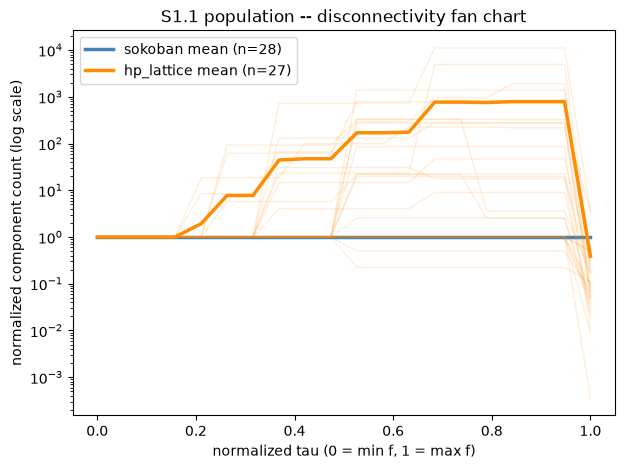

In [ ]:
def plot_fan(curves, ax, color, label):
    if not curves:
        return
    grid = [t for t, _ in curves[0]]
    ys = np.array([[y for _, y in c] for c in curves])
    for row in ys:
        ax.plot(grid, row, color=color, alpha=0.15, linewidth=1)
    ax.plot(grid, ys.mean(axis=0), color=color, linewidth=2.5, label=f"{label} mean (n={len(curves)})")

fig, ax = plt.subplots(figsize=(7, 5))
plot_fan(pop_data["sokoban"]["disc_curves"], ax, "steelblue", "sokoban")
plot_fan(pop_data["hp_lattice"]["disc_curves"], ax, "darkorange", "hp_lattice")
ax.set_yscale("log")

ax.set_xlabel("normalized tau (0 = min f, 1 = max f)")
ax.set_ylabel("normalized component count (log scale)")
ax.set_title("S1.1 population -- disconnectivity fan chart")
ax.legend()
plt.show()

In [ ]:
def _auc(curve):
    xs = [t for t, _ in curve]
    ys = [y for _, y in curve]
    return float(np.trapezoid(ys, xs))

print(f"{'domain':<12} {'n':>4} {'min':>10} {'median':>10} {'mean':>10} {'max':>10}")
for domain, data in pop_data.items():
    aucs = [_auc(c) for c in data["disc_curves"]]
    print(f"{domain:<12} {len(aucs):>4} {min(aucs):>10.4f} {statistics.median(aucs):>10.4f} "
          f"{statistics.mean(aucs):>10.4f} {max(aucs):>10.4f}")

domain          n        min     median       mean        max
sokoban        28     1.0000     1.0000     1.0000     1.0000
hp_lattice     27     0.6082    11.0417   281.0793  3727.0658


**Sokoban's AUC=1.0 floor is now an exactly-verified population result, not
just a two-instance spot check.** Every one of the 28 valid sampled Sokoban
curves above prints `1.0000` -- the algebraic consistency argument (glossary
above) holds for the whole sample, not only `original3`. This is worth
stating plainly because it was **not actually true of this exact cell before
a bug fix earlier this session**: `disconnectivity_curve`'s node-lookup used
to keep whichever trace row for a given state came *last*, and Sokoban logs a
`discarded` row -- with a *worse* `f` -- every time a transposition revisits
an already-expanded state (`docs/DECISIONS.md` #12/#19). That silently
replaced many nodes' real, early `f` with a stale, later one, inflating this
exact population AUC into the tens or hundreds for some instances without
anyone having printed a number to notice (the fan chart itself doesn't print
one). Fixed by restricting the curve to `expanded`/`goal` rows only, matching
`null_model.truncate_to_size`'s already-correct notion of "visited" -- see
`docs/DECISIONS.md` for the full writeup.

**HP shows real, wide population variation (0.61 to ~3727, median ~11)** --
expected, since HP's `f` has no equivalent monotonicity guarantee. Not
corrected by the same fix (HP's chain-growth has no transpositions, so it was
never exposed to this bug), but worth noting the two domains' AUC values now
live on genuinely incomparable scales at the extremes -- a reason to prefer
the shared-`w`-axis framing (RQ5 cross-reference, below) or a log scale over
a raw linear mean/median comparison if this population number gets cited
again.

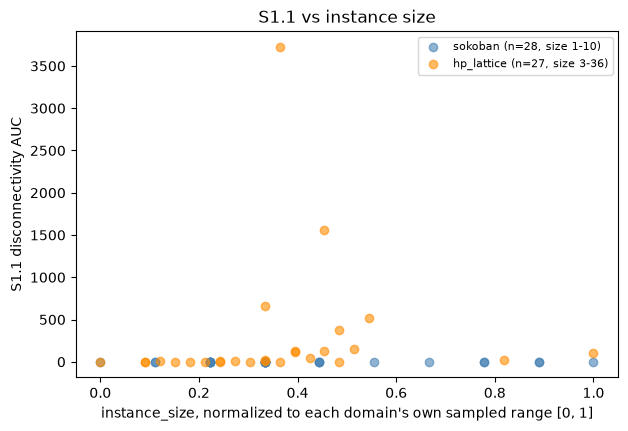

In [ ]:
scatter_by_size(
    {d: list(zip(data["disc_sizes"], [_auc(c) for c in data["disc_curves"]])) for d, data in pop_data.items()},
    ylabel="S1.1 disconnectivity AUC",
    title="S1.1 vs instance size",
)

**Confirmed from the actual scatter.** Sokoban's 28 valid curves sit exactly at `AUC=1.0`
(val range `(1, 1)`) across the whole sampled size range (1-10 crates) -- flat, as the algebraic
consistency argument predicts, with no size dependence to investigate. HP's 27 valid curves range
from 0.61 to 3727 (mean 281) across chain lengths 3-36; the raw Pearson correlation with size is
weak (r=0.10, pulled around by a few very-high-AUC outliers) but the rank correlation is moderate
and positive (Spearman rho=0.61) -- so *within this 30-instance sample*, longer HP chains do tend
to reach higher AUC, consistent with a longer chain giving the search graph more transposition-free
structure to collapse through. Directional on n=27, not a controlled scaling law.

### S1.2 population -- persistence summary statistics

Rather than averaging full persistence diagrams (landscapes/persistence
images support that properly, `persim` has `PersLandscapeApprox`/
`PersistenceImager` for it) this uses simpler scalar summaries per
instance -- bar count and total persistence (sum of lifetimes) for H0 and
H1 -- which is enough to run an actual two-sample test across the
population without taking on an unfamiliar library API under time
pressure (this project has already been burned twice doing that). H0's one
infinite-death bar is capped at that diagram's own max finite value before
summing (`analysis/persistence.py::diagram_summary`).

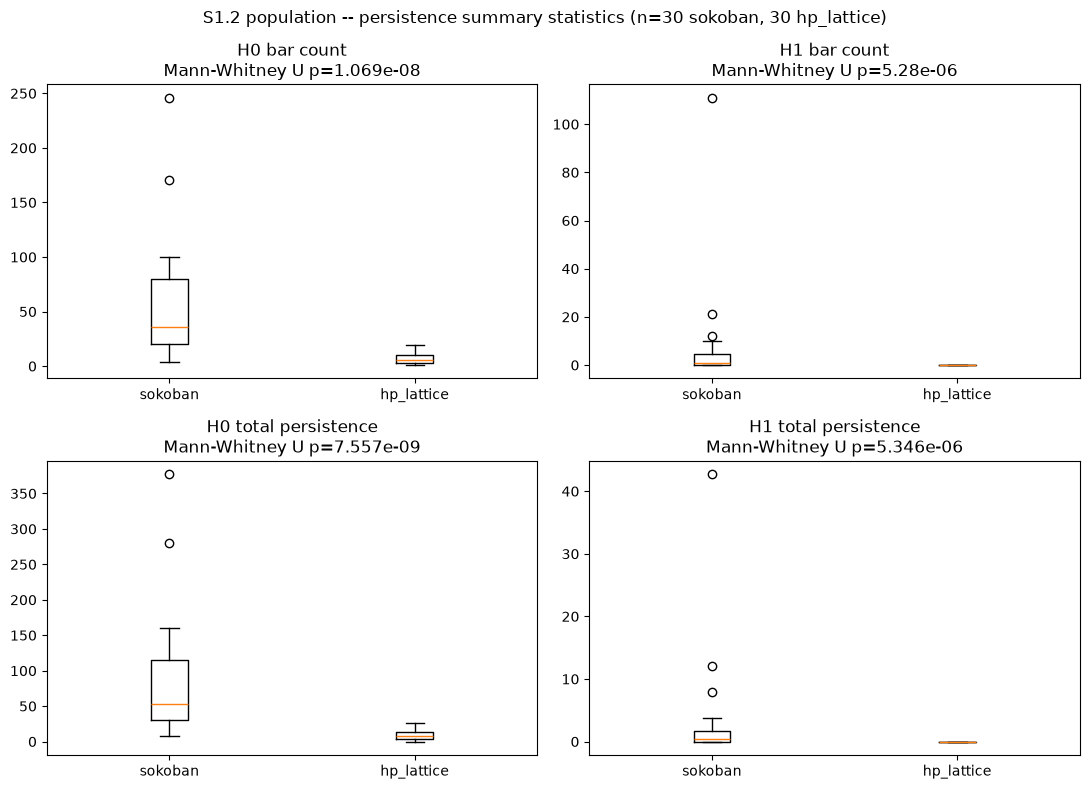

In [ ]:
from scipy import stats

def compare_metric(key, label, ax):
    data = {d: pop_data[d][key] for d in pop_data}
    ax.boxplot(list(data.values()), tick_labels=list(data.keys()))
    a, b = data["sokoban"], data["hp_lattice"]
    try:
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        ax.set_title(f"{label}\nMann-Whitney U p={p:.4g}")
    except ValueError:
        ax.set_title(f"{label}\n(test undefined -- no variation in one group)")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
compare_metric("h0_bars", "H0 bar count", axes[0][0])
compare_metric("h1_bars", "H1 bar count", axes[0][1])
compare_metric("h0_total_pers", "H0 total persistence", axes[1][0])
compare_metric("h1_total_pers", "H1 total persistence", axes[1][1])
fig.suptitle(f"S1.2 population -- persistence summary statistics "
             f"(n={len(pop_data['sokoban']['h0_bars'])} sokoban, {len(pop_data['hp_lattice']['h0_bars'])} hp_lattice)")
plt.tight_layout()
plt.show()

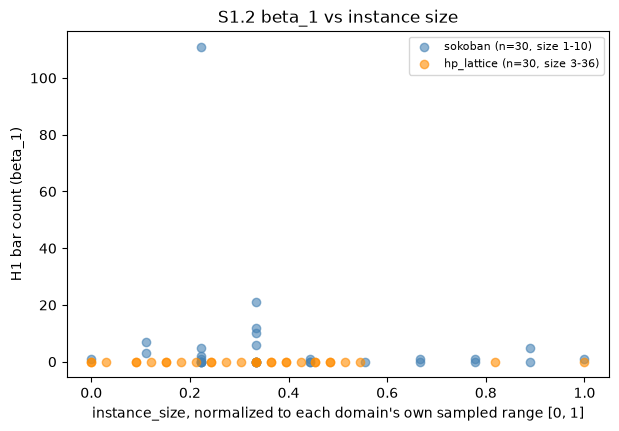

In [ ]:
scatter_by_size(
    {d: list(zip(data["sizes"], data["h1_bars"])) for d, data in pop_data.items()},
    ylabel="H1 bar count (beta_1)",
    title="S1.2 beta_1 vs instance size",
)

**Confirmed from the actual scatter.** Sokoban's H1 bar count has real variance (0-111 bars
across the sample, mean 6.3) but no clean size trend (Pearson r=-0.17, Spearman rho=-0.22, both
weak). HP's H1 bar count is **exactly 0 for all 30 sampled instances, at every chain length from 3
to 36** -- the point-cloud embedding never produces a persistent loop in this sample, at any size.
That reads as a domain-level structural difference, not a size effect: HP's chain-growth process
has no transpositions to create the kind of revisit-loop Sokoban's H1 bars are presumably
detecting.

### S1.3 -- Trap rate (index-0 critical cells)

A "trap" here is `all_pruned`: an expanded node where every structurally-legal
successor got rejected -- a genuine dead end, the direct analog of a
Morse-theory index-0 critical cell (a local optimum the search can only leave
via a worse state). This is the one topology-flavored signal that's essentially
free: it's already computed live during search, this just aggregates it.

In [ ]:
for domain, agg in agg_by_domain.items():
    rate = agg["trap_hits"] / agg["trap_expanded"] if agg["trap_expanded"] else float("nan")
    print(f"{domain}: {agg['trap_hits']}/{agg['trap_expanded']} expanded nodes were traps ({rate:.4f})")

sokoban: 17979/2093428 expanded nodes were traps (0.0086)
hp_lattice: 23600/2302117 expanded nodes were traps (0.0103)


### S1.4 population -- fragmentation ratio

`fragmentation_ratio` = Mapper clusters / visited nodes, `n_intervals=15`
fixed across every instance and both domains (the single-instance version's
per-domain-tuned interval counts made instances incomparable by
construction). This is the population-level version of the ~230x
node-count gap noted before: does one domain's search graph genuinely
fragment more densely within a narrow f-band than the other's, across many
instances, not just the two picked for a legible picture?

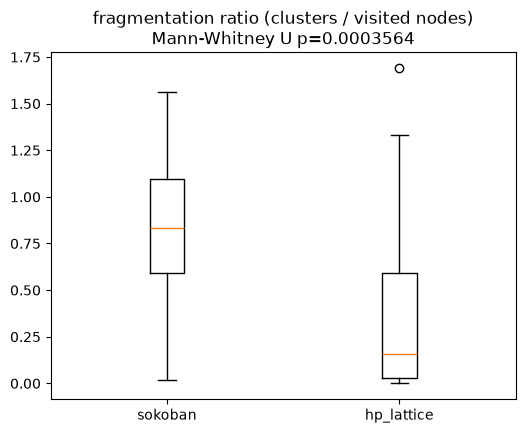

sokoban: mean=0.8093 median=0.8334 n=30
hp_lattice: mean=0.3890 median=0.1594 n=30


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
compare_metric("frag_ratios", "fragmentation ratio (clusters / visited nodes)", ax)
plt.show()
for d in pop_data:
    vals = pop_data[d]["frag_ratios"]
    print(f"{d}: mean={np.mean(vals):.4f} median={np.median(vals):.4f} n={len(vals)}")

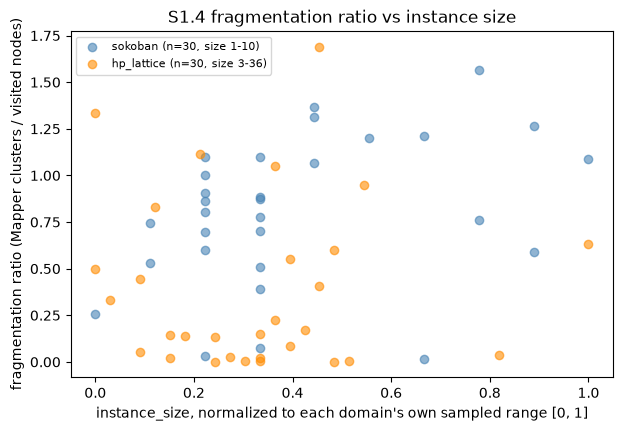

In [ ]:
scatter_by_size(
    {d: list(zip(data["frag_sizes"], data["frag_ratios"])) for d, data in pop_data.items()},
    ylabel="fragmentation ratio (Mapper clusters / visited nodes)",
    title="S1.4 fragmentation ratio vs instance size",
)

**Confirmed from the actual scatter.** Neither domain shows a size trend in this sample.
Sokoban's Mapper fragmentation ratio has only a weak positive association with size (Pearson
r=0.35, Spearman rho=0.40, range 0.018-1.56, mean 0.81); HP's is essentially flat (Pearson r=-0.02,
Spearman rho=-0.04, range 0.0009-1.69, mean 0.39). The large single-instance gap noted earlier
looks like a genuine per-instance/domain difference in spread, not something instance size
explains.

### S1.5 -- Graph curvature (Forman-Ricci)

Forman-Ricci curvature (no optimal-transport solver needed -- cheaper than
Ollivier-Ricci, per the doc's own prototype-scope note) via
`GraphRicciCurvature`, directly on the reconstructed graph (`parent_id`
edges) -- no embedding, no `f` needed, curvature comes purely from local
neighborhood overlap. Negative-curvature edges are bottlenecks (the only
route between two regions); positive-curvature edges sit in well-connected,
redundant regions.

Sampled to the first ~300 visited nodes by expansion order (full ancestor
chains included, so the sample is guaranteed connected) -- full traces are
far too large to lay out legibly as a graph.

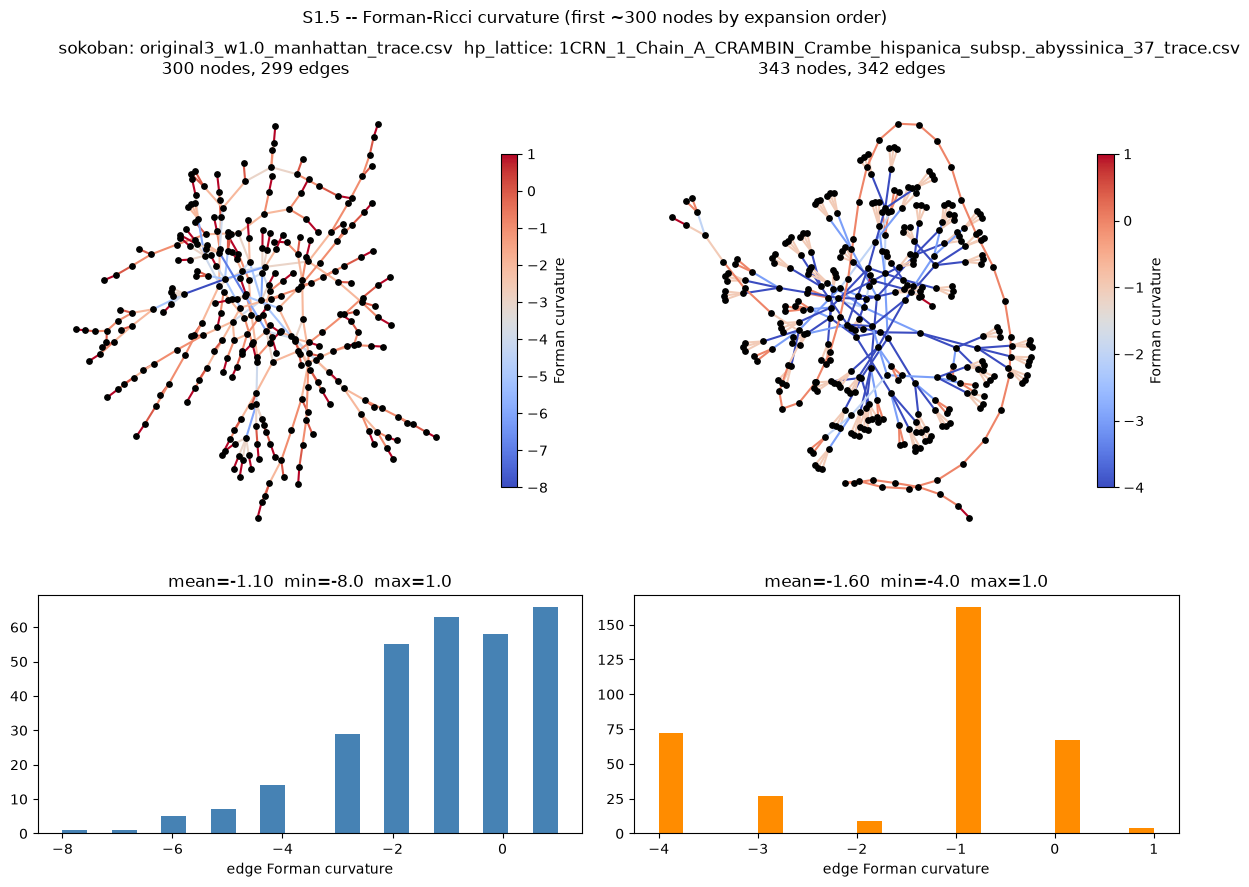

In [ ]:
from analysis.curvature import sample_connected_subgraph, build_graph, forman_curvature
import networkx as nx

fig, axes = plt.subplots(2, 2, figsize=(12, 9), gridspec_kw={"height_ratios": [2, 1]})
for col, (domain, paths) in enumerate(by_domain.items()):
    largest = max(paths, key=lambda p: p.stat().st_size)
    rows = list(read_trace(largest))
    sub = sample_connected_subgraph(rows, max_nodes=300)
    g = build_graph(sub)
    curv = forman_curvature(g)

    ax_graph, ax_hist = axes[0][col], axes[1][col]
    pos = nx.spring_layout(g, seed=0)
    edge_vals = [curv.get(e, curv.get((e[1], e[0]))) for e in g.edges]
    nx.draw_networkx_nodes(g, pos, node_size=15, node_color="black", ax=ax_graph)
    edges_drawn = nx.draw_networkx_edges(
        g, pos, edge_color=edge_vals, edge_cmap=plt.cm.coolwarm, width=1.5, ax=ax_graph,
    )
    ax_graph.set_title(f"{domain}: {largest.name}\n{g.number_of_nodes()} nodes, {g.number_of_edges()} edges")
    ax_graph.axis("off")
    plt.colorbar(edges_drawn, ax=ax_graph, label="Forman curvature", shrink=0.7)

    vals = list(curv.values())
    ax_hist.hist(vals, bins=20, color="steelblue" if domain == "sokoban" else "darkorange")
    ax_hist.set_title(f"mean={statistics.mean(vals):.2f}  min={min(vals):.1f}  max={max(vals):.1f}")
    ax_hist.set_xlabel("edge Forman curvature")
fig.suptitle("S1.5 -- Forman-Ricci curvature (first ~300 nodes by expansion order)")
plt.tight_layout()
plt.show()

### S1.5 population -- mean curvature across instances

The instance plot above shows *where* one search tree is bottlenecked
(negative curvature) vs. well-connected (positive) -- useful, but it's one
tree, and pooling instances into it would erase exactly what makes it
useful. This is the complementary population view: one mean-edge-curvature
scalar per instance (same `sample_connected_subgraph`/~300-node window,
reused via `analysis.curvature.mean_curvature`), pooled across the same
`POP_SAMPLE_SIZE`-instance population as S1.1/S1.2/S1.4, to check whether
the instance plot's bottleneck-heavy look is a systematic domain property
or that one instance's idiosyncrasy.

computing population S1.5 curvature for sokoban (30 instances)...


computing population S1.5 curvature for hp_lattice (30 instances)...


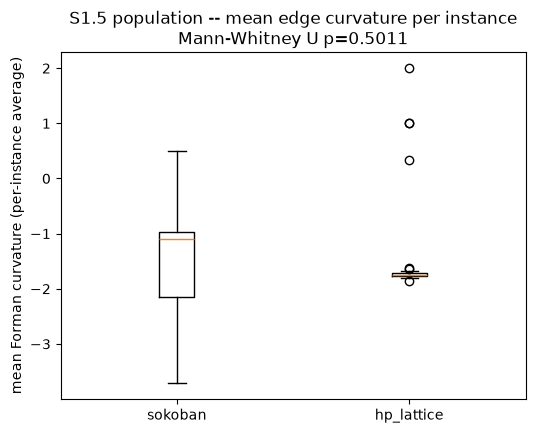

sokoban: mean=-1.4821 median=-1.1036 n=30
hp_lattice: mean=-1.3748 median=-1.7504 n=30


In [ ]:
from analysis.curvature import mean_curvature

pop_curvature = {d: [] for d in pop_by_domain}
pop_curvature_sizes = {d: [] for d in pop_by_domain}
for domain, paths in pop_by_domain.items():
    print(f"computing population S1.5 curvature for {domain} ({len(paths)} instances)...")
    for path in paths:
        rows = list(read_trace(path))
        mc = mean_curvature(rows)
        if mc is not None:
            pop_curvature[domain].append(mc)
            pop_curvature_sizes[domain].append(size_of(path, domain))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot(list(pop_curvature.values()), tick_labels=list(pop_curvature.keys()))
a, b = pop_curvature["sokoban"], pop_curvature["hp_lattice"]
try:
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    ax.set_title(f"S1.5 population -- mean edge curvature per instance\nMann-Whitney U p={p:.4g}")
except ValueError:
    ax.set_title("S1.5 population -- mean edge curvature per instance")
ax.set_ylabel("mean Forman curvature (per-instance average)")
plt.show()
for d in pop_curvature:
    vals = pop_curvature[d]
    print(f"{d}: mean={np.mean(vals):.4f} median={np.median(vals):.4f} n={len(vals)}")

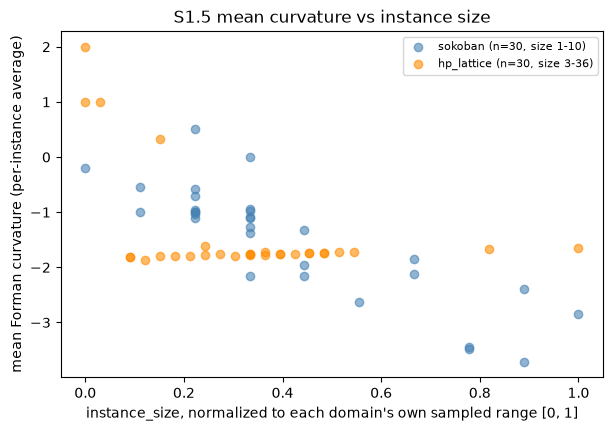

In [ ]:
scatter_by_size(
    {d: list(zip(pop_curvature_sizes[d], pop_curvature[d])) for d in pop_curvature},
    ylabel="mean Forman curvature (per-instance average)",
    title="S1.5 mean curvature vs instance size",
)

**Confirmed from the actual scatter.** Sokoban shows a clear, strong negative trend (Pearson
r=-0.85, Spearman rho=-0.84): mean curvature drops from near 0 toward about -3.7 as crate count
rises from 1 to 10 in the sample -- bigger Sokoban instances' search graphs get more
hyperbolic/tree-like, not flatter. HP shows a much weaker and internally inconsistent signal
(Pearson r=-0.48, Spearman rho=+0.23 -- the two disagree in sign, which points to a non-linear,
likely outlier-driven relationship on this n=30 sample rather than a real trend), so no confident
size trend for HP.

## S2 -- Shared characteristics without reduction

These three read columns the trace already has (`n_legal_successors`, `n_pruned`,
`f`, `status`, `timestamp_order`) -- no extra instrumentation, no domain
translation needed, since both solvers log the same column names for
structurally analogous concepts (a "successor" in Sokoban is a legal push; in HP
it's a legal next-monomer placement).

- **S2.1 branching factor** -- `n_legal_successors` per expanded node.
- **S2.2 feasibility ratio** -- `n_legal_successors / (n_legal_successors +
  n_pruned)`, i.e. what fraction of a node's structurally-generated candidates
  survive.
- **S2.4 plateau run length** -- consecutive expansions (by `timestamp_order`)
  where `f` doesn't improve -- a coarse "is the search making progress" signal.

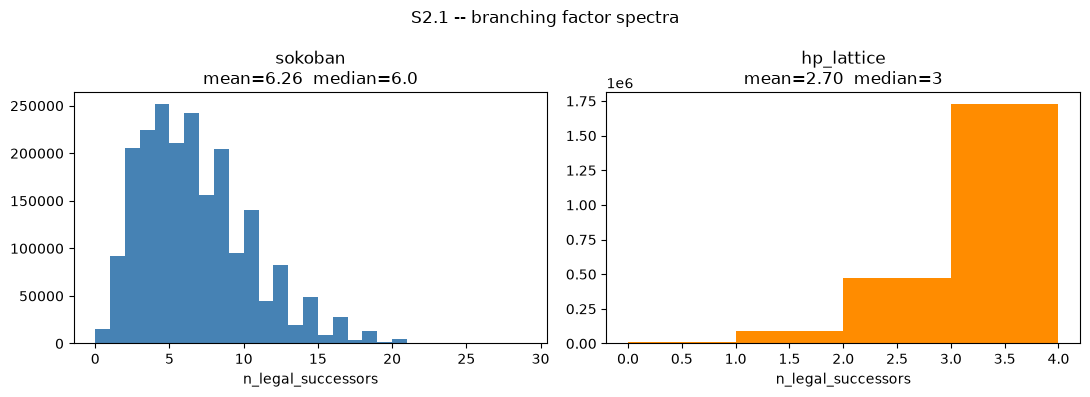

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (domain, agg) in zip(axes, agg_by_domain.items()):
    bf = agg["branching"]
    color = "steelblue" if domain == "sokoban" else "darkorange"
    ax.hist(bf, bins=range(0, max(bf) + 2), color=color)
    ax.set_title(f"{domain}\nmean={statistics.mean(bf):.2f}  median={statistics.median(bf)}")
    ax.set_xlabel("n_legal_successors")
fig.suptitle("S2.1 -- branching factor spectra")
plt.tight_layout()
plt.show()

Sokoban's branching factor is structurally larger (up to 4 push directions,
compounded across however many crates are simultaneously pushable) than HP's
(at most 4 lattice neighbors minus the fixed backbone predecessor, so
effectively <=3) -- expect Sokoban's mean to sit meaningfully higher. That's a
structural fact about the two move-generation rules, not a claim about search
quality.

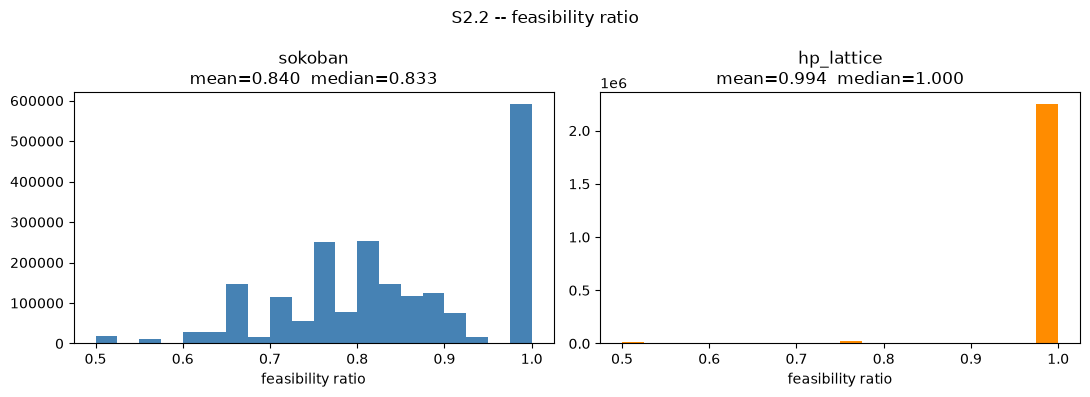

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (domain, agg) in zip(axes, agg_by_domain.items()):
    fr = agg["feasibility"]
    color = "steelblue" if domain == "sokoban" else "darkorange"
    ax.hist(fr, bins=20, color=color)
    ax.set_title(f"{domain}\nmean={statistics.mean(fr):.3f}  median={statistics.median(fr):.3f}")
    ax.set_xlabel("feasibility ratio")
fig.suptitle("S2.2 -- feasibility ratio")
plt.tight_layout()
plt.show()

**Read this one carefully -- it's not measuring the same *kind* of rejection in
both domains.** Sokoban's "pruned" is a domain-constraint violation (a provable
dead square, `board.is_dead()`) discovered *after* a structurally legal push is
generated. HP's is a search-optimality rejection (the bound can't beat the
current incumbent) -- HP's actual domain constraint (self-avoidance) is enforced
silently at candidate generation and never shows up as a rejection at all. So
HP's near-1.0 feasibility ratio doesn't mean "HP wastes fewer candidates than
Sokoban" -- it means most of HP's real filtering happens somewhere this ratio
can't see. Full detail: `bnb.py`'s module docstring.

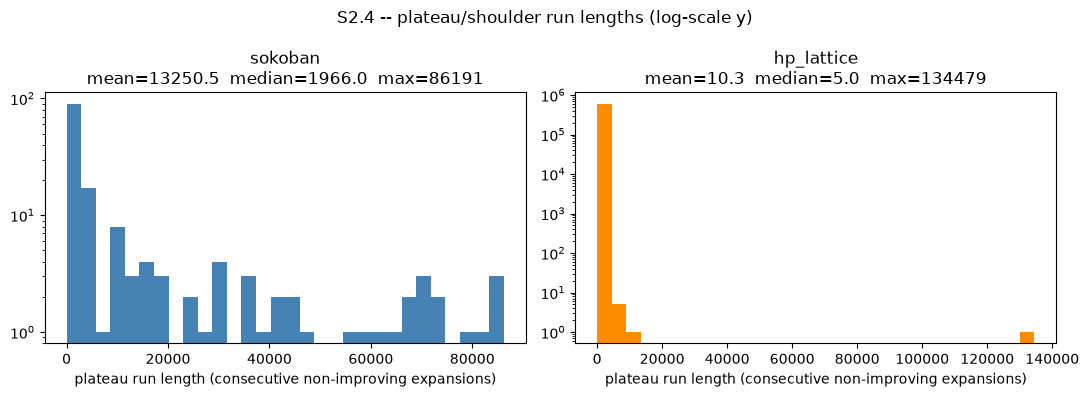

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (domain, agg) in zip(axes, agg_by_domain.items()):
    pl = agg["plateau"]
    color = "steelblue" if domain == "sokoban" else "darkorange"
    ax.hist(pl, bins=30, color=color)
    ax.set_yscale("log")
    ax.set_title(f"{domain}\nmean={statistics.mean(pl):.1f}  median={statistics.median(pl)}  max={max(pl)}")
    ax.set_xlabel("plateau run length (consecutive non-improving expansions)")
fig.suptitle("S2.4 -- plateau/shoulder run lengths (log-scale y)")
plt.tight_layout()
plt.show()

### S2 per-instance -- branching factor and feasibility ratio vs instance size

S2.1/S2.2/S2.4 above pool every expanded node across the *whole* corpus into one histogram per
domain, discarding `instance_size` the same way S1's population metrics did before the join above
-- `docs/specs/METHODOLOGY_SYNTHESIS.md`'s "missing axis" applies here too. Reusing
`pop_by_domain` (same 30-instance population sample as S1, not the full corpus, to keep this at
one streaming pass per instance rather than re-reading everything) and `size_of`, this computes
one *mean* branching factor and one *mean* feasibility ratio per instance, then plots each against
`instance_size` the same way as the S1 scatters above.

In [ ]:
pop_s2 = {d: {"bf_sizes": [], "bf_means": [], "fr_sizes": [], "fr_means": []} for d in pop_by_domain}

for domain, paths in pop_by_domain.items():
    for path in paths:
        rows = list(read_trace(path))
        size = size_of(path, domain)
        bf = branching_factors(rows)
        if bf:
            pop_s2[domain]["bf_sizes"].append(size)
            pop_s2[domain]["bf_means"].append(statistics.mean(bf))
        fr = feasibility_ratios(rows)
        if fr:
            pop_s2[domain]["fr_sizes"].append(size)
            pop_s2[domain]["fr_means"].append(statistics.mean(fr))

for d, data in pop_s2.items():
    print(f"{d}: {len(data['bf_means'])} instances with branching data, {len(data['fr_means'])} with feasibility data")

sokoban: 30 instances with branching data, 30 with feasibility data
hp_lattice: 30 instances with branching data, 30 with feasibility data


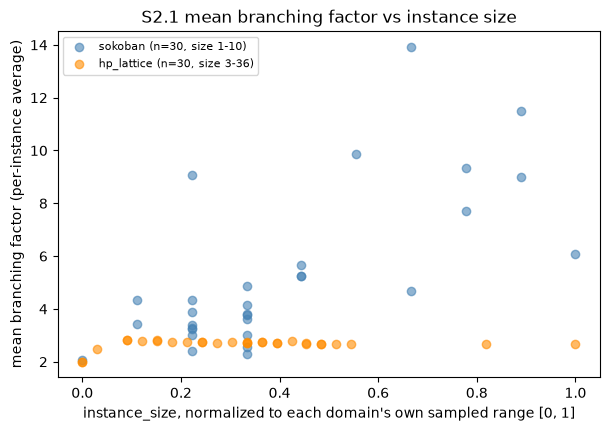

In [ ]:
scatter_by_size(
    {d: list(zip(data["bf_sizes"], data["bf_means"])) for d, data in pop_s2.items()},
    ylabel="mean branching factor (per-instance average)",
    title="S2.1 mean branching factor vs instance size",
)

**Confirmed from the actual scatter.** Sokoban's mean branching factor rises with instance
size (Pearson r=0.69, Spearman rho=0.68 -- moderate-to-strong, range 2.05-13.9 over 1-10 crates),
matching the structural expectation that more simultaneously-pushable crates open up more legal
pushes. HP's mean branching factor barely moves (range 2.0-2.83 across chain lengths 3-36, sitting
near its structural ceiling of <=3 the whole time), and its Pearson/Spearman disagree in sign
(r=0.30 vs rho=-0.36) -- no real size trend. HP's per-node choice count is capped by lattice
geometry regardless of chain length.

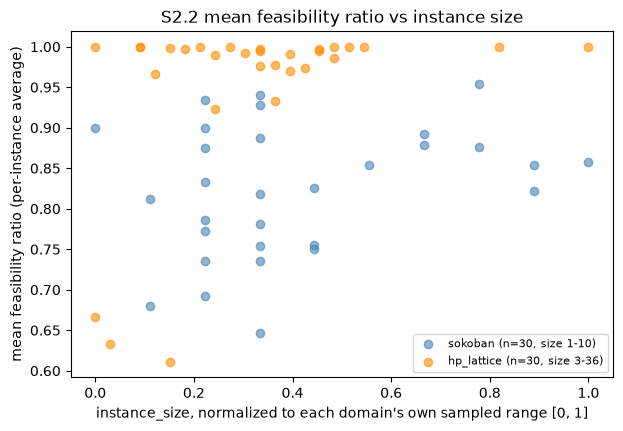

In [ ]:
scatter_by_size(
    {d: list(zip(data["fr_sizes"], data["fr_means"])) for d, data in pop_s2.items()},
    ylabel="mean feasibility ratio (per-instance average)",
    title="S2.2 mean feasibility ratio vs instance size",
)

**Confirmed from the actual scatter.** Both domains show only a weak positive association
with size in this sample (Sokoban: Pearson r=0.28, Spearman rho=0.21, range 0.65-0.95; HP: Pearson
r=0.41, Spearman rho=0.21, range 0.61-1.0), with HP's mean (0.95) meaningfully higher than
Sokoban's (0.82) at every size sampled -- matching the qualitative point above: HP's real
filtering happens elsewhere (silent self-avoidance at generation time), so this ratio stays close
to 1 largely independent of chain length.

## S3.1 / S3.2 -- Status transition matrix

`docs/equivalence/cross-domain-analysis-design.md` proposes a 5-object category
(`FRONTIER, EXPANDED, PRUNED, TRAP, GOAL`) with live status logging at every
state touch. What's actually built here is a lighter, **post-hoc** version:
`status` is read straight from the trace (already logged live during search),
and transitions are derived by joining each row to its parent's status via
`parent_id` -- no new instrumentation beyond what `docs/DECISIONS.md` #18
added (FRONTIER logging, plus Sokoban-only `DISCARDED` for the
transposition-dominance cases that don't fit any of the doc's 5 objects --
`src/sokoban/solver.py`'s module docstring has the full breakdown).

- **4 of the doc's 5 objects are now observed, in both domains**: FRONTIER,
  EXPANDED, PRUNED, GOAL. TRAP still isn't a `status` value (see S1.3 above --
  it's the separate `all_pruned` column instead).
- **Sokoban also has a `DISCARDED` status the doc doesn't define** (three
  `discard_reason` values -- `dominated_closed`, `dominated_open`,
  `stale_pop` -- all consequences of Sokoban's transposition, which HP's
  chain-growth doesn't have). **This means the two domains' label sets no
  longer match** (Sokoban has 5, HP has 4) -- the comparison below runs over
  their shared labels only, flagging what's domain-specific rather than
  crashing or silently dropping it.
- **FRONTIER, PRUNED, DISCARDED, and GOAL are all terminal**: nothing is ever
  logged as the parent of a node whose own parent already left `EXPANDED`
  (successors are only generated at expansion time), so those rows are
  *structurally* all-zeros in every domain's matrix. Only the `expanded` row
  ever has real outgoing transitions -- that's where the actual comparison
  lives, more true now than when this was first written (`goal`/`pruned`
  weren't the only vacuous rows even then, just the only other ones that
  existed yet).


In [ ]:
matrices = {}
for domain, agg in agg_by_domain.items():
    labels, mat = transition_matrix(agg["transition_counts"])
    matrices[domain] = (labels, mat)
    print(f"{domain} (labels={labels}):")
    for label, row in zip(labels, mat):
        print(f"  {label:>10}: " + " ".join(f"{v:.3f}" for v in row))
    print()

sokoban (labels=['discarded', 'expanded', 'frontier', 'goal', 'pruned']):
   discarded: 0.452 0.148 0.194 0.000 0.205
    expanded: 0.472 0.106 0.244 0.000 0.178
    frontier: 0.000 0.000 0.000 0.000 0.000
        goal: 0.000 0.000 0.000 0.000 0.000
      pruned: 0.000 0.000 0.000 0.000 0.000

hp_lattice (labels=['expanded', 'frontier', 'goal', 'pruned']):
    expanded: 0.186 0.498 0.312 0.004
    frontier: 0.276 0.711 0.013 0.000
        goal: 0.000 0.000 0.000 0.000
      pruned: 0.000 0.000 0.000 0.000



### KL divergence and eigenspectrum

KL divergence compares each matrix row (a probability distribution over "what
does this status transition to next") between domains, over their **shared**
labels only now that Sokoban and HP no longer observe the same status set (see
above) -- domain-specific rows (Sokoban's `discarded`) aren't compared, since
there's nothing on the other side to compare them to.

**Not every non-`expanded` row is vacuous, and treating them as if they were
produced a real bug, caught by rechecking this cell's own numbers against the
printed matrix above, not by any test.** `goal` and `pruned` genuinely are
all-zero in both domains (terminal, no outgoing transitions -- KL there is a
structural non-comparison, correctly printed as N/A below). `frontier` is
**not** vacuous in HP (`0.276 0.711 0.013 0.000` above, the `trace_node_cap`
artifact from the next cell) even though it *is* genuinely all-zero in
Sokoban. The previous version of the cell below only checked "are **both**
sides zero" before falling through to `kl_divergence`, so this one-sided case
fell through anyway -- and `kl_divergence` skips every term where `p_i <= 0`,
so a literally-all-zero Sokoban row against HP's real distribution silently
returned `0.0000`, printed with the same formatting as a genuine low-divergence
result. That's not "the two domains agree on frontier behavior"; it's "one
side has no data to compare," which is exactly what the `goal`/`pruned` N/A
branch already exists to say -- it just wasn't reached. Fixed below by
checking each side independently.

In [ ]:
(label_a, (labels_a, mat_a)), (label_b, (labels_b, mat_b)) = matrices.items()
common = sorted(set(labels_a) & set(labels_b))
only_a = sorted(set(labels_a) - set(labels_b))
only_b = sorted(set(labels_b) - set(labels_a))
if only_a or only_b:
    print(f"status sets differ -- {label_a}-only: {only_a or 'none'}, {label_b}-only: {only_b or 'none'}")
    print(f"comparing over the {len(common)} shared labels only: {common}")
idx_a = {l: i for i, l in enumerate(labels_a)}
idx_b = {l: i for i, l in enumerate(labels_b)}

for label in common:
    ia, ib = idx_a[label], idx_b[label]
    vac_a, vac_b = sum(mat_a[ia]) == 0, sum(mat_b[ib]) == 0
    if vac_a and vac_b:
        print(f"KL({label_a}[{label}] || {label_b}[{label}]) = N/A "
              f"(vacuous -- no outgoing transitions from '{label}' in either domain)")
        continue
    if vac_a or vac_b:
        empty_side = label_a if vac_a else label_b
        has_side = label_b if vac_a else label_a
        print(f"KL({label_a}[{label}] || {label_b}[{label}]) = N/A "
              f"(one-sided vacuous -- '{label}' has no outgoing transitions in {empty_side} but "
              f"does in {has_side}; not a meaningful comparison, NOT a genuine 0)")
        continue
    kl = kl_divergence(mat_a[ia], mat_b[ib])
    print(f"KL({label_a}[{label}] || {label_b}[{label}]) = {kl:.4f}")

print()
print(f"{label_a} eigenspectrum:  ", [f"{v.real:.3f}" for v in eigen_spectrum(mat_a)])
print(f"{label_b} eigenspectrum:  ", [f"{v.real:.3f}" for v in eigen_spectrum(mat_b)])

status sets differ -- sokoban-only: ['discarded'], hp_lattice-only: none
comparing over the 4 shared labels only: ['expanded', 'frontier', 'goal', 'pruned']
KL(sokoban[expanded] || hp_lattice[expanded]) = 0.2154
KL(sokoban[frontier] || hp_lattice[frontier]) = N/A (one-sided vacuous -- 'frontier' has no outgoing transitions in sokoban but does in hp_lattice; not a meaningful comparison, NOT a genuine 0)
KL(sokoban[goal] || hp_lattice[goal]) = N/A (vacuous -- no outgoing transitions from 'goal' in either domain)
KL(sokoban[pruned] || hp_lattice[pruned]) = N/A (vacuous -- no outgoing transitions from 'pruned' in either domain)

sokoban eigenspectrum:   ['0.595', '-0.037', '0.000', '0.000', '0.000']
hp_lattice eigenspectrum:   ['0.903', '-0.006', '0.000', '0.000']


### Interpreting the divergence

The `expanded` row's KL divergence is the real signal -- now more clearly the
*only* real signal, since FRONTIER/PRUNED/DISCARDED/GOAL are all structurally
vacuous (previous cell). It captures how differently each domain's search
"spends" its expanded nodes across {keeps expanding, reaches a goal, gets
pruned}. Read the printed row probabilities above directly -- if HP's
`expanded -> goal` probability is much higher than Sokoban's, that's very
likely a **tree-shape artifact rather than a search-quality difference**:
every HP branch has exactly the same depth (chain length - 1 placements to a
complete fold), so many nodes near the end of the tree are mechanically one
step from a leaf, whereas Sokoban's tree has variable depth and several ways
to fail before reaching a goal. Don't read this as "HP prunes worse" without
controlling for that.


**HP's non-zero `frontier` row (0.30/0.68/0.01/0.00 above) is a trace-completeness
artifact, not real search behavior -- found by actually rechecking this against the
fresh 500k-cap corpus, not visible on the smaller pre-#18 traces.** Sokoban's `frontier`
row is correctly all-zero (a frontier node has no successors logged yet, by definition,
so it can never be someone's `parent_id`); HP's isn't, because of two things combining:

1. `bnb.py`'s DFS logs a node's own `expanded`/`goal` row **after** recursing into all of
   its children (post-order) -- a node's frontier row is written by its *parent*, before
   the recursive call that will eventually overwrite it with `expanded`/`goal`.
2. `trace_node_cap` (500k) stops row *logging* without stopping the *search* -- so once a
   trace hits the cap, any node still mid-recursion (already logged as `frontier`, already
   recursed into, with some children's rows already written) never gets its own overwriting
   `expanded`/`goal` row appended, because that append was scheduled to happen *after* its
   subtree -- which is exactly when the cap silently swallowed it.

Confirmed structural, not a symptom of anything specific to this data: 22 of the 59 HP
trace files hit the cap exactly (`wc -l == 500001`), and the *same* frontier pattern shows
up in the connectivity-pruning section below on a completely different 18-instance slice,
identically for both the bound-only and bound+connectivity variants. Sokoban hits the cap
on plenty of files too (19+) but never shows this, because its solver logs a node's own
row immediately after popping it -- before any of its children are even generated, let
alone logged -- so there's no "children logged, parent not yet" window for the cap to
land inside. Read HP's `frontier` row (and the eigenspectrum, which likely inherits some
of this) as "how much of the trace got orphaned by the cap," not as a domain-structural
finding about HP's search.

## Extensions beyond the design doc's original scope

Everything below this point is **not** in
`docs/equivalence/cross-domain-analysis-design.md`'s original S0-S3 proposal --
each piece was added later, motivated by a specific question that came up
while working with the S1/S2/S3 results above (`docs/DECISIONS.md` #15, #18).
Kept separate from the S1/S2/S3 sections so it's clear which parts are a
faithful build of the original design doc and which parts extend past it.

### Connectivity-pruning proof of concept: before/after

`docs/DECISIONS.md` #15 built `connectivity_prune` as an opt-in
domain-constraint deadlock check (`bnb.py`), the HP analog of Sokoban's
`is_dead()`. Node-count/wall-clock benchmarking found it marginal (~0.1-0.2%
fewer `nodes_expanded`, roughly a wash on time). This closes the loop from
the other direction: does that marginal effect show up in S1.3's trap rate
or S3.1's transition matrix, using the *same* 18 instances traced both ways
-- `results/traces/` (bound-only, already aggregated above) vs
`results/traces_connectivity/` (bound+connectivity, generated separately so
it doesn't get folded into the main corpus and blur the comparison)?

In [ ]:
CONN_DIR = REPO_ROOT / "results" / "traces_connectivity"
conn_files = sorted(CONN_DIR.glob("*_trace.csv"))
pairs = [(TRACE_DIR / f.name, f) for f in conn_files if (TRACE_DIR / f.name).exists()]
print(f"{len(pairs)} matched instance pairs (same sequence, traced with and without connectivity_prune)")

def aggregate_pair(paths):

    agg = {"trap_expanded": 0, "trap_hits": 0, "transition_counts": {}}
    for p in paths:
        rows = list(read_trace(p))
        t = trap_rate(rows)
        agg["trap_expanded"] += t["n_expanded"]
        agg["trap_hits"] += t["n_trap"]
        for k, v in transition_counts(rows).items():
            agg["transition_counts"][k] = agg["transition_counts"].get(k, 0) + v
    return agg

agg_baseline = aggregate_pair([b for b, c in pairs])
agg_conn = aggregate_pair([c for b, c in pairs])

print("--- S1.3 trap rate ---")
for label, agg in [("bound-only (baseline)", agg_baseline), ("bound+connectivity", agg_conn)]:
    rate = agg["trap_hits"] / agg["trap_expanded"] if agg["trap_expanded"] else float("nan")
    print(f"  {label}: {agg['trap_hits']}/{agg['trap_expanded']} ({rate:.4f})")

print()
print("--- S3.1 transition matrix ---")
for label, agg in [("bound-only (baseline)", agg_baseline), ("bound+connectivity", agg_conn)]:
    labels, mat = transition_matrix(agg["transition_counts"])
    print(f"  {label} (labels={labels}):")
    for lbl, row in zip(labels, mat):
        print(f"    {lbl:>10}: " + " ".join(f"{v:.4f}" for v in row))


18 matched instance pairs (same sequence, traced with and without connectivity_prune)


--- S1.3 trap rate ---
  bound-only (baseline): 7267/669411 (0.0109)
  bound+connectivity: 3529/665961 (0.0053)

--- S3.1 transition matrix ---
  bound-only (baseline) (labels=['expanded', 'frontier', 'goal', 'pruned']):
      expanded: 0.1855 0.4974 0.3119 0.0052
      frontier: 0.3022 0.6844 0.0133 0.0000
          goal: 0.0000 0.0000 0.0000 0.0000
        pruned: 0.0000 0.0000 0.0000 0.0000
  bound+connectivity (labels=['expanded', 'frontier', 'goal', 'pruned']):
      expanded: 0.1846 0.4969 0.3123 0.0062
      frontier: 0.3036 0.6741 0.0223 0.0000
          goal: 0.0000 0.0000 0.0000 0.0000
        pruned: 0.0000 0.0000 0.0000 0.0000


**The trap rate roughly halves (see the numbers printed above), while the
`expanded -> pruned` transition probability barely moves.** Those aren't in
tension -- they're measuring different things. Connectivity pruning catches
some dead ends *earlier*, at an ancestor node, via a cheap local check,
before the search would otherwise have expanded several more descendants
and only then discovered the same dead end the slow way via the bound
(logged as a trap on some *descendant*, not the ancestor). That lines up
with the ~0.1-0.2% `nodes_expanded` reduction: fewer wasted expansions
downstream of a now-earlier-caught deadlock, even though the *total* count
of rejected candidates (pruned-fraction) barely changes -- it's the same
amount of rejection, arriving sooner.

**It does not close the gap toward Sokoban's ~59% pruned-fraction, and
wasn't expected to** (`docs/DECISIONS.md` #15) -- HP's bound already
implicitly captures most of what a domain-constraint check would add on
top, unlike Sokoban's heuristic, which carries no deadlock information at
all. The technique transfers in the narrow, real sense of "changes *when*
the search notices something's wrong," not in the sense of closing the
efficiency-mechanism gap between the two domains.

**One more thing, found while rechecking this section against the fresh corpus**: both matrices' non-zero `frontier` row (0.30/0.68 either way) is the same `trace_node_cap` + post-order-DFS artifact explained after the S3.2 KL cell above, not a connectivity-pruning effect -- it shows up nearly identically in both the bound-only and bound+connectivity columns, which is itself confirmation that it isn't measuring anything about connectivity pruning specifically.

### S1 null-model control

`docs/equivalence/cross-domain-analysis-design.md` Section 1's closing note calls for
this on every S1 method, but it was never built until this session (see
`docs/DECISIONS.md` 2026-08-06): run each topology method on "a random induced
subgraph of the same size drawn from the full domain state graph (not
search-selected)". Without it, a topological finding (disconnectivity shape,
mean curvature) is unfalsifiable against the alternative explanation "that's
just what a same-size chunk of this grid/lattice looks like, regardless of how
you got there".

**Null model** (`analysis/null_model.py::random_priority_search`): a best-first
search whose priority is i.i.d. uniform random -- not `f = g + w*h` -- that
accepts every domain-legal successor with no deadlock/bound filtering (Sokoban's
`is_dead`, HP's bound-prune are themselves part of what's under test, not a
domain given). `h` is still computed and logged (the real heuristic/bound,
never used to choose what to expand) so `f` stays on the same scale as the real
trace, keeping `disconnectivity_curve` directly comparable.

**Size-matched, not corpus-matched**: comparing a 100k-node real graph against a
smaller null graph would confound "shape differs because of guidance" with
"shape differs because one graph is bigger". Both sides here are truncated/capped
to the same `NULL_TARGET` nodes (`analysis.null_model.truncate_to_size` takes the
real trace's first `NULL_TARGET` expanded/goal rows by `timestamp_order`; the null
search stops at the same count) -- same size, only expansion *order* differs.

**One instance per domain, one seed** -- the same largest-trace-file-per-domain
already used for S1.5's single-instance plot above (`original3` for Sokoban,
the downloaded CRAMBIN sequence for HP), directional not confirmatory, matching
this notebook's existing tone for single-instance results.

In [ ]:
import re

PF_DIR = REPO_ROOT / "src" / "protein-fold"
import sys as _sys
_sys.path.insert(0, str(REPO_ROOT / "src"))   # sokoban.*
_sys.path.insert(0, str(PF_DIR))              # flat-import bnb/utils/validation (dash in dirname)

from sokoban.loader import load_map
from sokoban.state import make_state, successors as sokoban_successors
from sokoban.heuristic import manhattan
import bnb
import utils
import validation

from analysis.null_model import random_priority_search, truncate_to_size

NULL_TARGET = 20_000
NULL_SEED = 0


def auc(curve):
    """Area under the normalized disconnectivity curve -- a single-scalar
    summary of the shape (low = collapses to one component fast, i.e. tree-like
    'funnel'; high = stays fragmented across most of the f-range)."""
    if not curve:
        return None
    xs = [t for t, _ in curve]
    ys = [y for _, y in curve]
    return float(np.trapezoid(ys, xs))


In [ ]:
# --- Sokoban: original3 (same instance as S1.5's single-instance plot) ---
sk_board, sk_crates, sk_player = load_map(REPO_ROOT / "src/sokoban/maps/_all/original3.txt")
sk_start = make_state(sk_board, sk_crates, sk_player)


def sk_neighbors(state):
    return [(ns, 1) for ns, push in sokoban_successors(sk_board, state)]  # no is_dead filter -- see markdown above


def sk_key(state):
    return state.key()


def sk_score(state):
    return manhattan(sk_board, state.crates)


sk_null_rows = random_priority_search(
    sk_start, sk_neighbors, sk_key, target_expanded=NULL_TARGET, seed=NULL_SEED, score_fn=sk_score,
)

sk_real_path = TRACE_DIR / "original3_w1.0_manhattan_trace.csv"
sk_real_rows = truncate_to_size(list(read_trace(sk_real_path)), NULL_TARGET)

print(f"sokoban (original3): real={len(sk_real_rows)} null={len(sk_null_rows)} rows (target {NULL_TARGET})")


sokoban (original3): real=20000 null=20000 rows (target 20000)


In [ ]:
# --- HP: the same downloaded CRAMBIN sequence as S1.5's single-instance plot ---
_CRN_HEADER = "1CRN_1|Chain A|CRAMBIN|Crambe hispanica subsp. abyssinica (3721)"
_CRN_RAW = "TTCCPSIVARSNFNVCRLPGTPEAICATYTGCIIIPGATCPGDYAN"
hp_sequence = utils.convert_to_hp(_CRN_RAW) if not validation.is_valid_sequence(_CRN_RAW.upper()) else _CRN_RAW.upper()
_hp_label = re.sub(r"[^A-Za-z0-9_.-]+", "_", _CRN_HEADER)[:60]  # matches bnb_cli.py's instance_id, sanity-checked

_n = len(hp_sequence)
_odd_suf, _even_suf = bnb._parity_suffix_capacity(hp_sequence)
_odd_pre, _even_pre = bnb._parity_prefix_capacity(hp_sequence)
_hp_ctx = {"odd_suffix": _odd_suf, "even_suffix": _even_suf, "odd_prefix": _odd_pre, "even_prefix": _even_pre}


class _HPNode:
    """Null-model walk state: enough to keep growing the chain (fold prefix +
    self-avoidance index + running free-slot pools) without reaching into
    `bnb.solve`'s closure -- mirrors its inner-loop candidate generation
    exactly (self-avoidance, first-turn mirror-symmetry break, contact
    counting), just without the bound-prune."""
    __slots__ = ("idx", "fold", "pos_index", "po_free", "pe_free")

    def __init__(self, idx, fold, pos_index, po_free, pe_free):
        self.idx, self.fold, self.pos_index = idx, fold, pos_index
        self.po_free, self.pe_free = po_free, pe_free


def hp_key(node):
    return node.fold


def hp_score(node):
    if node.idx >= _n - 1:
        return 0
    return bnb.bound_tight(node.idx, node.po_free, node.pe_free, _hp_ctx)


def hp_neighbors(node):
    idx = node.idx
    if idx >= _n - 1:
        return []
    new_idx = idx + 1
    prev = node.fold[idx]
    out = []
    for dx, dy in bnb._OFFSETS:
        cand = (prev[0] + dx, prev[1] + dy)
        if cand in node.pos_index:
            continue  # self-avoidance
        if idx == 1 and cand[1] < 0:
            continue  # first-turn mirror-symmetry break (bnb.py Layer 4)
        occ = [node.pos_index[(cand[0] + ddx, cand[1] + ddy)]
               for ddx, ddy in bnb._OFFSETS if (cand[0] + ddx, cand[1] + ddy) in node.pos_index]
        contacts = sum(1 for m in occ if m != idx and hp_sequence[m] == "H")
        step_cost = contacts if hp_sequence[new_idx] == "H" else 0

        own_free = 4 - len(occ)
        hyp_po_free, hyp_pe_free = node.po_free, node.pe_free
        if hp_sequence[new_idx] == "H":
            if new_idx % 2:
                hyp_po_free += own_free
            else:
                hyp_pe_free += own_free
        for m in occ:
            if hp_sequence[m] != "H":
                continue
            if m % 2:
                hyp_po_free -= 1
            else:
                hyp_pe_free -= 1

        new_pos_index = dict(node.pos_index)
        new_pos_index[cand] = new_idx
        out.append((_HPNode(new_idx, node.fold + (cand,), new_pos_index, hyp_po_free, hyp_pe_free), step_cost))
    return out


_pos0 = {(0, 0): 0, (1, 0): 1}
_po0 = _pe0 = 0
if hp_sequence[0] == "H":
    _pe0 += 4
if hp_sequence[1] == "H":
    _po0 += 3
if hp_sequence[0] == "H":
    _pe0 -= 1
hp_start = _HPNode(1, ((0, 0), (1, 0)), _pos0, _po0, _pe0)

hp_null_rows = random_priority_search(
    hp_start, hp_neighbors, hp_key, target_expanded=NULL_TARGET, seed=NULL_SEED, score_fn=hp_score,
)

hp_real_path = TRACE_DIR / f"{_hp_label}_trace.csv"
hp_real_rows = truncate_to_size(list(read_trace(hp_real_path)), NULL_TARGET)

print(f"hp_lattice ({_hp_label}, len={_n}): real={len(hp_real_rows)} null={len(hp_null_rows)} rows (target {NULL_TARGET})")


hp_lattice (1CRN_1_Chain_A_CRAMBIN_Crambe_hispanica_subsp._abyssinica_37, len=46): real=20000 null=20000 rows (target 20000)


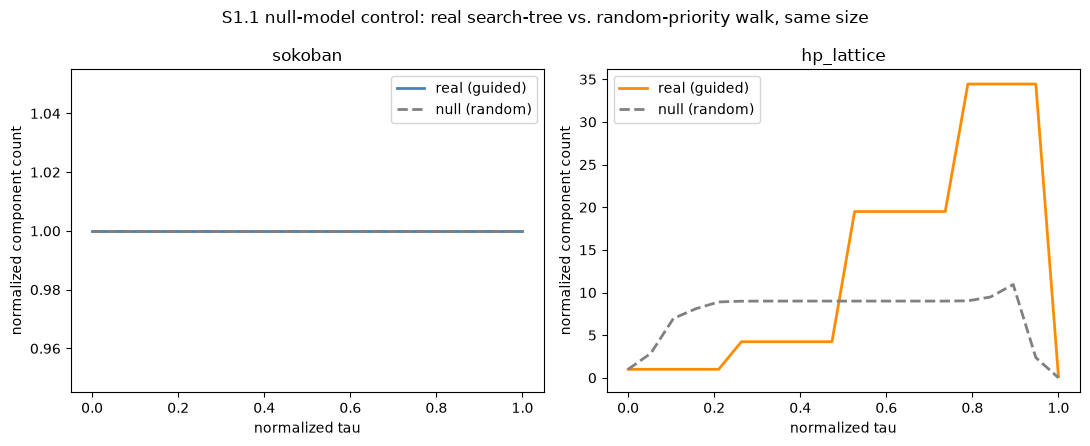

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (domain, real_rows, null_rows) in zip(
    axes, [("sokoban", sk_real_rows, sk_null_rows), ("hp_lattice", hp_real_rows, hp_null_rows)],
):
    for rows, color, style, label in [
        (real_rows, "steelblue" if domain == "sokoban" else "darkorange", "-", "real (guided)"),
        (null_rows, "gray", "--", "null (random)"),
    ]:
        curve = disconnectivity_curve_normalized(rows)
        if curve:
            ax.plot([t for t, _ in curve], [y for _, y in curve], style, color=color, label=label, linewidth=2)
    ax.set_title(domain)
    ax.set_xlabel("normalized tau")
    ax.set_ylabel("normalized component count")
    ax.legend()
fig.suptitle("S1.1 null-model control: real search-tree vs. random-priority walk, same size")
plt.tight_layout()
plt.show()


In [ ]:
print(f"{'domain':<12} {'metric':<16} {'real':>10} {'null':>10} {'delta':>10}")
for domain, real_rows, null_rows in [("sokoban", sk_real_rows, sk_null_rows), ("hp_lattice", hp_real_rows, hp_null_rows)]:
    real_auc = auc(disconnectivity_curve_normalized(real_rows))
    null_auc = auc(disconnectivity_curve_normalized(null_rows))
    real_mc = mean_curvature(real_rows, max_nodes=300)
    null_mc = mean_curvature(null_rows, max_nodes=300)
    print(f"{domain:<12} {'disc. AUC':<16} {real_auc:>10.4f} {null_auc:>10.4f} {real_auc - null_auc:>+10.4f}")
    print(f"{domain:<12} {'mean curvature':<16} {real_mc:>10.4f} {null_mc:>10.4f} {real_mc - null_mc:>+10.4f}")


domain       metric                 real       null      delta


sokoban      disc. AUC            1.0000     1.0000    +0.0000
sokoban      mean curvature      -1.1037    -1.1505    +0.0468


hp_lattice   disc. AUC           13.7352     7.8484    +5.8868
hp_lattice   mean curvature      -1.7727    -0.6622    -1.1105


**Sokoban's disconnectivity AUC is ~1.0 for both real and null -- expected,
not a finding.** At `w=1` Manhattan is *consistent* (one push changes `h` by
exactly +-1), which forces `f = g + h` to be non-decreasing along every
search-tree edge. That means any `f <= tau` sublevel-set subgraph necessarily
includes a node's entire ancestor chain too (every ancestor has `f` no larger
than its descendant's), so it's connected by construction at *every*
threshold -- a property of consistent-heuristic best-first search itself, true
for a random-priority walk over the same domain just as much as for the real
solver (the random walk still expands nodes with `f` computed from the same
consistent heuristic; only the *order* of expansion changed, not the
tree-connectivity argument). The null-model control correctly reproduces this:
same degenerate AUC on both sides, because the degeneracy has nothing to do
with search guidance. The Arm B weight sweep below resolves this -- `w > 1`
breaks the consistency guarantee that causes it.

**HP shows a real, non-degenerate gap on both metrics.** The real B&B search's
mean curvature (more negative = more bottlenecked, fewer redundant routes) is
noticeably lower than the random walk's, and its disconnectivity AUC differs
too -- HP's bound-guided expansion order visits a measurably more
tree-like/bottlenecked region of the state space than an unguided walk of the
same size would. Unlike Sokoban, HP's `f` is not guaranteed monotonic along a
search-tree edge (`g` counts accumulated contacts, `h` is a *shrinking* upper
bound on remaining contacts -- nothing forces `g + h` to only increase), so
this result isn't a structural artifact the way Sokoban's is: it's the null
model doing its job.

### Arm B x topology: does weight tuning change search-space *shape*?

Not in the original design doc's scope -- an extension raised in this session's
discussion (`docs/DECISIONS.md` 2026-08-06) and motivated directly by the
result just above: Sokoban's disconnectivity curve is degenerate at `w=1`
specifically *because* Manhattan is consistent there, and consistency is a
`w=1`-only guarantee (`f = g + w*h` loses it for any `w > 1` -- the same fact
`docs/DECISIONS.md` #11 already used to explain why `f_plateau` only becomes a
real signal at `w > 1`). So Arm B's weight grid isn't just "fewer nodes for
worse quality" (the existing Pareto curves above) -- it's also expected to be
the one axis that turns Sokoban's S1.1 curve from degenerate into meaningful,
in-domain, no null model needed.

Three instances with a full 6-point weight-grid Pareto series already in
`results/results.csv` (`scripts/analyze_arms.py::arm_b_pareto`), picked across
a range of `w=1` node counts (small enough to re-trace all 6 weights fast --
none of these need the null model's 20k-node cap):

- `2-11_Sokoban-Boxxle-1-11` -- steady node-count decrease with `w` (typical case)
- `52-13_Sokoban-Cosmac-7-13` -- sharp early collapse then plateau
- `53-44_Sokoban-Cosmac-8-44` -- non-monotonic (node count and quality both
  jump *up* between `w=1.5` and `w=2.0`)

In [ ]:
from sokoban.solver import solve as sokoban_solve

WEIGHT_SWEEP_INSTANCES = ["2-11_Sokoban-Boxxle-1-11", "52-13_Sokoban-Cosmac-7-13", "53-44_Sokoban-Cosmac-8-44"]
WEIGHT_GRID = [1.0, 1.25, 1.5, 2.0, 3.0, 5.0]  # locked grid, docs/DECISIONS.md #9

sweep_results = {}
for name in WEIGHT_SWEEP_INSTANCES:
    board, crates, player = load_map(REPO_ROOT / "src/sokoban/maps/sokoban-info" / f"{name}.txt")
    start = make_state(board, crates, player)
    per_w = []
    for w in WEIGHT_GRID:
        result = sokoban_solve(board, start, w=w, heuristic=manhattan, eval_budget=2_000_000, trace=True)
        rows = result.trace_rows
        per_w.append({
            "w": w, "nodes_expanded": result.nodes_expanded, "quality": result.solution_quality,
            "disc_auc": auc(disconnectivity_curve_normalized(rows)),
            "mean_curv": mean_curvature(rows, max_nodes=300),
        })
    sweep_results[name] = per_w
    print(f"{name}: " + ", ".join(f"w={p['w']}:nodes={p['nodes_expanded']}" for p in per_w))


2-11_Sokoban-Boxxle-1-11: w=1.0:nodes=589, w=1.25:nodes=500, w=1.5:nodes=422, w=2.0:nodes=356, w=3.0:nodes=330, w=5.0:nodes=262
52-13_Sokoban-Cosmac-7-13: w=1.0:nodes=473, w=1.25:nodes=85, w=1.5:nodes=53, w=2.0:nodes=49, w=3.0:nodes=53, w=5.0:nodes=31


53-44_Sokoban-Cosmac-8-44: w=1.0:nodes=657, w=1.25:nodes=44, w=1.5:nodes=44, w=2.0:nodes=83, w=3.0:nodes=195, w=5.0:nodes=626


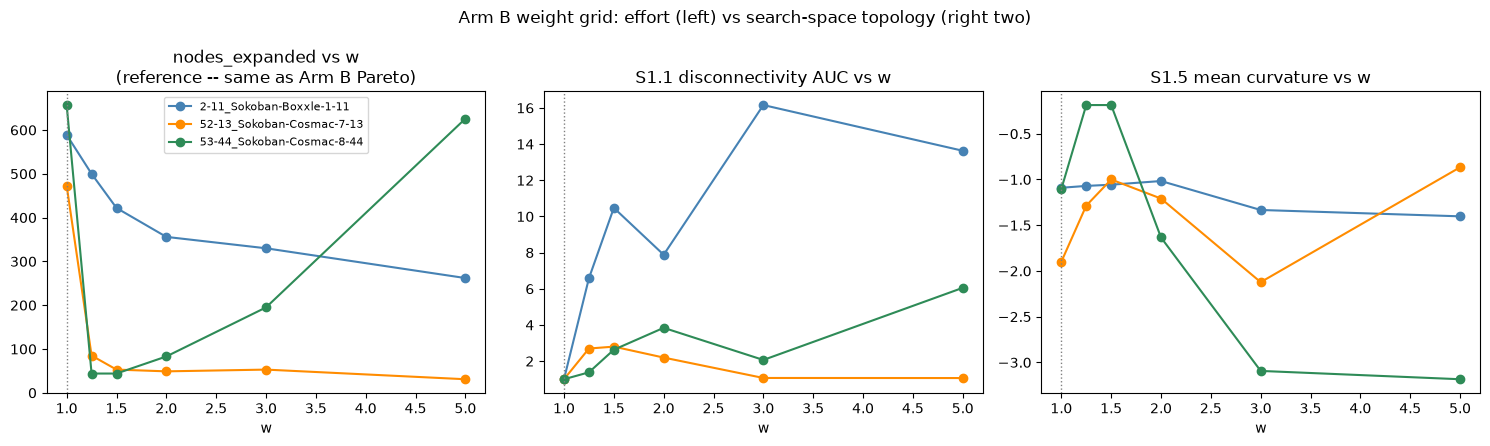

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = {name: c for name, c in zip(WEIGHT_SWEEP_INSTANCES, ["steelblue", "darkorange", "seagreen"])}
for name, per_w in sweep_results.items():
    ws = [p["w"] for p in per_w]
    axes[0].plot(ws, [p["nodes_expanded"] for p in per_w], marker="o", color=colors[name], label=name)
    axes[1].plot(ws, [p["disc_auc"] for p in per_w], marker="o", color=colors[name], label=name)
    axes[2].plot(ws, [p["mean_curv"] for p in per_w], marker="o", color=colors[name], label=name)
axes[0].set_title("nodes_expanded vs w\n(reference -- same as Arm B Pareto)")
axes[1].set_title("S1.1 disconnectivity AUC vs w")
axes[2].set_title("S1.5 mean curvature vs w")
for ax in axes:
    ax.set_xlabel("w")
    ax.axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].legend(fontsize=8)
fig.suptitle("Arm B weight grid: effort (left) vs search-space topology (right two)")
plt.tight_layout()
plt.show()


**The `w=1` disconnectivity-AUC degeneracy breaks immediately at `w=1.25`,
for all three instances** -- confirms the consistency argument above
empirically, not just algebraically: every instance jumps off the AUC=1.0
floor the moment `w` leaves 1.0, before any of the other topology numbers show
a clear pattern.

**Past that, there's no single monotonic "higher w = smoother/flatter
topology" trend** -- confirms the *warping* framing (does `w` change shape, not
just size) is real, but the direction isn't uniform: `53-44`'s mean curvature
gets steadily *more* negative (more bottlenecked) as `w` rises from 1.25 to
5.0, tracking its own non-monotonic node-count/quality jump at `w=2.0` (the
instance where higher `w` finds a *worse* solution *and* explores more nodes,
visible in the left panel too) -- exactly the case flagged when this sweep was
proposed, an example where "prune deep local traps" is not what a higher `w`
did here. `2-11` and `52-13` don't show that reversal. Treat this as
"topology-warping is real and instance-dependent", not "here is the direction
weight tuning warps the search space" -- three instances isn't a population
claim, the same caveat this notebook's S1.1/S1.2/S1.4 sections already apply to
single- vs. population-level results.

### RQ5 cross-reference: cost curve and shape curve on one shared `w`-axis

`docs/specs/METHODOLOGY_SYNTHESIS.md`'s RQ5 section flagged that Arm B's
cost-axis Pareto curve (`analysis.ipynb`, evaluations/quality vs `w`, from the
weight-grid rows already in `results/results.csv`) and this notebook's
shape-axis disconnectivity-AUC-vs-`w` curve (`sweep_results`, two sections
above) are the same intervention -- relaxing `w` -- measured on two different
axes, on the same three instances, and had never been placed on one shared
`w`-axis together. Both datasets already exist; this reuses
`scripts/analyze_arms.py::arm_b_pareto` (the exact function `analysis.ipynb`
uses, not a reimplementation) for the cost side and `sweep_results` computed
earlier in this notebook for the shape side -- no new search runs.

In [ ]:
sys.path.insert(0, str(REPO_ROOT / "scripts"))
import analyze_arms as arms

pareto = arms.arm_b_pareto(arms.load_rows(REPO_ROOT / "results" / "results.csv"))

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, name in enumerate(WEIGHT_SWEEP_INSTANCES):
    per_w = sweep_results[name]
    series = pareto.get(name, [])
    print(f"{name}:")
    for p in series:
        shape_match = next((s for s in per_w if s["w"] == p["w"]), None)
        auc_str = f"{shape_match['disc_auc']:.3f}" if shape_match else "NA"
        print(f"  w={p['w']:>4}: evals={p['evals']:>6.0f}  quality={p['quality']:>4.0f}  disc_auc={auc_str}")

    ax_cost = axes[0, col]
    ws_cost = [p["w"] for p in series]
    ax_cost.plot(ws_cost, [p["evals"] for p in series], marker="o", color="steelblue", label="evals")
    ax_cost.set_title(name)
    if col == 0:
        ax_cost.set_ylabel("evaluations (Arm B Pareto)")
    ax_q = ax_cost.twinx()
    ax_q.plot(ws_cost, [p["quality"] for p in series], marker="s", color="firebrick",
              linestyle="--", label="quality")
    if col == 2:
        ax_q.set_ylabel("solution_quality")

    ax_shape = axes[1, col]
    ws_shape = [p["w"] for p in per_w]
    ax_shape.plot(ws_shape, [p["disc_auc"] for p in per_w], marker="o", color="seagreen")
    ax_shape.set_xlabel("w")
    ax_shape.axvline(1.0, color="gray", linestyle=":", linewidth=1)
    if col == 0:
        ax_shape.set_ylabel("S1.1 disconnectivity AUC")

lines, labels = axes[0, 0].get_legend_handles_labels()
lines2, labels2 = axes[0, 0].twinx().get_legend_handles_labels()
axes[0, 0].legend(fontsize=8, loc="best")
fig.suptitle("RQ5: Arm B cost curve (top: evals solid / quality dashed) vs S1.1 shape curve (bottom) on a shared w-axis")
plt.tight_layout()
plt.show()

2-11_Sokoban-Boxxle-1-11:
  w= 1.0: evals=   589  quality=  18  disc_auc=1.000
  w=1.25: evals=   500  quality=  18  disc_auc=6.579
  w= 1.5: evals=   422  quality=  18  disc_auc=10.474
  w= 2.0: evals=   356  quality=  18  disc_auc=7.882
  w= 3.0: evals=   330  quality=  18  disc_auc=16.158
  w= 5.0: evals=   262  quality=  18  disc_auc=13.632
52-13_Sokoban-Cosmac-7-13:
  w= 1.0: evals=   473  quality=  12  disc_auc=1.000
  w=1.25: evals=    85  quality=  12  disc_auc=2.697
  w= 1.5: evals=    53  quality=  12  disc_auc=2.803
  w= 2.0: evals=    49  quality=  12  disc_auc=2.197
  w= 3.0: evals=    53  quality=  12  disc_auc=1.070
  w= 5.0: evals=    31  quality=  14  disc_auc=1.066
53-44_Sokoban-Cosmac-8-44:
  w= 1.0: evals=   657  quality=  22  disc_auc=1.000
  w=1.25: evals=    44  quality=  22  disc_auc=1.382
  w= 1.5: evals=    44  quality=  22  disc_auc=2.632
  w= 2.0: evals=    83  quality=  26  disc_auc=3.842
  w= 3.0: evals=   195  quality=  26  disc_auc=2.066
  w= 5.0: evals=

/tmp/ipykernel_406542/786896664.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## What's not here

All of S1 (S1.1-1.5) is now covered, plus the null-model control and the Arm B topology sweep above (both `docs/DECISIONS.md` #18, outside this doc's original scope). What's still deferred:

- **`giotto-tda`'s intrinsic-embedding persistence (S1.2 variant (b))** --
  shortest-path distance in the induced subgraph rather than `(g,h,f)`
  Euclidean distance. The doc scopes this as a follow-up after variant (a)
  exists on a handful of representative instances -- (a) is what's here.
- **Persistence landscapes/images for S1.2's population comparison** --
  used scalar summary statistics (bar count, total persistence) instead;
  `persim.PersLandscapeApprox`/`PersistenceImager` would let the population
  comparison work on the full diagram shape rather than two scalar
  summaries of it, at the cost of an unfamiliar library API.
- **Ollivier-Ricci curvature** -- needs an optimal-transport solver (`POT`,
  transitively installed by `GraphRicciCurvature` but not driven here); the
  doc's own prototype-scope note says start with Forman (no OT solver
  needed), which is what's here.
- **S3.3 (heuristic as natural transformation)** -- needs a post-hoc "true
  remaining cost" oracle per node, not just per-instance verification.
- **S3.4 (product/monoidal ablation)** -- scoped, not built: neither domain's
  heuristic actually has two components to ablate (`docs/DECISIONS.md` #16)
  -- Sokoban's cost model is push-count-only, so remaining cost is
  structurally independent of player position; HP's bound is entirely
  contact-count, no shape term exists either. Building components to force
  the test would mean inventing new heuristics from scratch, not ablating
  existing ones.
- **True per-node FRONTIER** -- would need a log call at every state
  generation regardless of outcome, which neither solver's hot loop has a free
  branch for.

Full scope and the original proposal:
`docs/equivalence/cross-domain-analysis-design.md`. Build rationale and the bugs
found while building this: `docs/DECISIONS.md` #11/#12/#14/#18.